In [48]:
from pathlib import Path

project_dir = Path.cwd()

image_path = project_dir/ "Sentinel2_Bulgaria_2019_08_26_RGB_StudyArea.tif"
csv_path = project_dir/ "PPI_Bulgaria_2019-08-26_1200_points.csv"

required_files=[csv_path, image_path]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Required file not found: {file_path.name}. Download the whole repository so that paths link properly."
        )
print(f"Working directory: {project_dir}")
print("All required input files were found.")

Working directory: c:\Users\Oliver\Desktop\Internship_revised
All required input files were found.


##### My internship task was written as follows:
#### 1. Data preprocessing
 1. Load the CSV into a geopandas.GeoDataFrame (or equivalent construct containing geometry primitives)
 2. Clean the data and deal with outliers
 3. Sample the raster RGB values at point locations

#### 2. Model the PPI values against the imagery using Python 
 1. Fit any kind of nonlinear model using RGB values as covariates and PPI values as the target
 2. Evaluate model performance appropriately
 3. Using the fitted model, infer PPI values across the extent of the raster and save the results to a GeoTIFF

#### 3. Interpret the obtained result
 Comment on the performance of the obtained model.

GeoPandas is similar to Pandas, but it is designed for working with geospatial data. I will use it to work with the CSV point data, and will use rasterio to read and process the satellite image.


In [49]:
%pip install geopandas
import geopandas as gpd
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Oliver\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [50]:
%pip install rasterio
import rasterio as rs

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Oliver\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Before I proceed with the task, I should explain the following three terms:

CRS (Coordinate reference system): A CRS defines how coordinates correspond to locations on Earth. In the CSV file only numbers in columns lat and lon are stored. Until further specification, we don't know which coordinate system, units and geodetic reference system is being used.

WGS 84 (World Geodetic system 1984): WGS 84 is a global reference system commonly used by GPS and online maps. It approximates planet Earth using an ellipsoid and defines its properties, for example its size, its position relative to Earth's centre of mass and the reference meridian used for calculating longitude.

EPSG: This is a registry of coordinate reference systems. Instead of specifying every property of a CRS every time it is used, we can identify a CRS using its EPSG code. This task uses the following two:

    1. EPSG:4326 - WGS 84: This CRS uses latitude and longitude as coordinates and degrees as coordinate units. The CSV file with PPI values is written assuming this is its CRS.
    2. EPSG:32635(WGS 84 / UTM zone 35N): This is a projected coordinate reference system that represents the relevant part of Earth's curved surface on a flat plane. Its coordinates are  called Easting and Northing and are measured in metres. This is the CRS of the satellite image.



#### 1.1: Load the CSV into a geopandas.GeoDataFrame (or equivalent construct containing geometry primitives):

To connect every point from CSV to a point on the satellite image, coordinate systems need to be aligned. The same point on Earth is denoted by 
- longitude 27.794803° E and latitude 43.575787° N in EPSG:4326 and
- Easting 564174.994 m and Northing 4825065.027 m in EPSG:32635.

In [ ]:
from shapely.geometry import Point

df=pd.read_csv(csv_path) #ordinary Pandas dataframe, nothing geospatial yet
geometry=[Point(xy) for xy in zip(df["lon"],df["lat"])]
#Look at each row, and look at columns lon and lat. For each lon and lat, make pairs out of them. For example, (27.794803,43.575787) is the first pair. 
#Then, iterate over all such pairs and make them a Point object. Return it as a list.

gdf=gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

In [52]:
gdf

,lon,lat,ppi,geometry
0,27.794803,43.575787,0.000000,POINT (27.7948 43.57579)
1,27.733058,43.539552,0.000000,POINT (27.73306 43.53955)
2,27.893484,43.540482,0.158373,POINT (27.89348 43.54048)
3,27.747776,43.478498,0.880115,POINT (27.74778 43.4785)
4,27.842234,43.548885,0.000000,POINT (27.84223 43.54888)
...,...,...,...,...
1195,27.847739,43.526514,0.345602,POINT (27.84774 43.52651)
1196,27.745650,43.546854,0.000000,POINT (27.74565 43.54685)
1197,27.760923,43.501372,0.074152,POINT (27.76092 43.50137)
1198,27.895837,43.473652,0.551250,POINT (27.89584 43.47365)


Geometry column is currently written in should be written in `EPSG:4326` instead of `EPSG:32635`, so I need to change the CRS. GeoPandas already has a function built for this purpose:

In [53]:
gdf_bul=gdf.to_crs(epsg=32635)

In [54]:
gdf_bul

,lon,lat,ppi,geometry
0,27.794803,43.575787,0.000000,POINT (564174.994 4825065.027)
1,27.733058,43.539552,0.000000,POINT (559224.967 4820994.958)
2,27.893484,43.540482,0.158373,POINT (572184.989 4821224.983)
3,27.747776,43.478498,0.880115,POINT (560474.991 4814224.964)
4,27.842234,43.548885,0.000000,POINT (568035.01 4822115.01)
...,...,...,...,...
1195,27.847739,43.526514,0.345602,POINT (568505.025 4819635.019)
1196,27.745650,43.546854,0.000000,POINT (560235.027 4821814.957)
1197,27.760923,43.501372,0.074152,POINT (561515.013 4816774.946)
1198,27.895837,43.473652,0.551250,POINT (572454.988 4813804.961)


#### 1.2 Clean the data and handle outliers appropriately

I wanted to check if all points in `gdf_bul` are within the satellite image. In `gdf_bul`, the following issues could occur:
- latitude and/or longitude fall outside of the raster extent
- latitude and/or longitude are Nan values
- PPI value is not in $[0,3]$
- PPI value is `NaN`.

 For the first two potential problems, I imported the `box` function from `shapely.geometry` and used it to define a rectangular polygon that represents the raster extent. After that, for all points from `gdf_bul`, I inspected whether they are inside of the image. For this, I used the `intersects()` method which will eliminate Nan values as well.

In [55]:
from shapely.geometry import box

In [56]:
s_image=rs.open(image_path)

bounds=s_image.bounds #bounds is a Rasterio BoundingBox containing the raster extent

bbox_polygon=box(bounds.left, bounds.bottom, bounds.right, bounds.top)


In [57]:
bounds

BoundingBox(left=556490.0, bottom=4811030.0, right=572810.0, top=4827840.0)

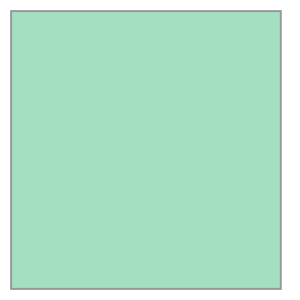

In [58]:
bbox_polygon

In [ ]:
points_within_or_on_edge = gdf_bul[gdf_bul.geometry.intersects(bbox_polygon)]
# The expression inside returns a Boolean series.
# This GeoDataFrame contains all points which are inside or on the boundary of the raster extent.

points_outside_or_nans=gdf_bul[~gdf_bul.geometry.intersects(bbox_polygon)]
# This GeoDataFrame contains all points outside of the raster extent and points with invalid coordinates.

print(points_outside_or_nans) #Let's print all longitude and latitude related problematic rows.

            lon        lat       ppi                        geometry
82    28.400000  43.490055  0.000000  POINT (613201.247 4816188.838)
120   27.791219  43.900000  0.000000  POINT (563541.809 4861070.389)
165         NaN  43.516563  0.000000                 POINT (NaN NaN)
250   27.785729        NaN  0.000000                 POINT (NaN NaN)
283   27.200000  43.582003  0.000000  POINT (516146.968 4825467.968)
475   27.896429        NaN  0.000000                 POINT (NaN NaN)
543   27.775199  43.150000  0.000000  POINT (563031.401 4777763.889)
588         NaN  43.503273  0.000000                 POINT (NaN NaN)
691   28.350000  43.553952  0.837433   POINT (609043.14 4823218.458)
798   27.702258        NaN  0.039000                 POINT (NaN NaN)
872   27.853996  43.850000  0.000000   POINT (568640.738 4855567.29)
903         NaN  43.547585  0.037054                 POINT (NaN NaN)
987   27.250000  43.555099  0.034430  POINT (520192.697 4822490.953)
1032  27.719088        NaN  0.0192

Problematic PPI values can be either NaN or outside of interval $[0,3]$.

In [60]:
nan_indexes=gdf_bul[gdf_bul["ppi"].isna()].index

print(nan_indexes)

Index([36, 113, 207, 318, 426, 517, 632, 740, 855, 966, 1083, 1178], dtype='int64')


In [61]:
improper_bound_indexes=gdf_bul[(gdf_bul["ppi"] < 0) | (gdf_bul["ppi"] > 3)].index

print(improper_bound_indexes)

Index([144, 381, 664, 1010], dtype='int64')


In [62]:
gdf_bul=points_within_or_on_edge.copy()

gdf_bul=gdf_bul[
    (gdf_bul["ppi"].notna()) & 
    (gdf_bul["ppi"]>=0) & 
    (gdf_bul["ppi"]<=3)
    ].copy()

gdf_bul=gdf_bul.reset_index(drop=True)

gdf_bul

,lon,lat,ppi,geometry
0,27.794803,43.575787,0.000000,POINT (564174.994 4825065.027)
1,27.733058,43.539552,0.000000,POINT (559224.967 4820994.958)
2,27.893484,43.540482,0.158373,POINT (572184.989 4821224.983)
3,27.747776,43.478498,0.880115,POINT (560474.991 4814224.964)
4,27.842234,43.548885,0.000000,POINT (568035.01 4822115.01)
...,...,...,...,...
1163,27.847739,43.526514,0.345602,POINT (568505.025 4819635.019)
1164,27.745650,43.546854,0.000000,POINT (560235.027 4821814.957)
1165,27.760923,43.501372,0.074152,POINT (561515.013 4816774.946)
1166,27.895837,43.473652,0.551250,POINT (572454.988 4813804.961)


I now need to deal with outliers. Only PPI values can potentially be outliers as I have dealt with coordinate-related issues earlier. In my original internship, I did the following:

- In statistics class at university, we defined outliers using John Tukey's definition. This means all points whose distance from 0.25 quantile leftward and 0.75 quantile rightward is greater than 1.5 * interquartile distance. I found all such points.
- Afterwards, I simply erased them.

This was fine since the emphasis of the internship was more on machine learning than on data cleaning. However, I wanted to be more thorough in this revised version. I have guaranteed with earlier code that all PPI values in gdf_bul are legitimate. I felt I had no excuse to erase points which seemed too extreme based on a somewhat arbitrary criterion like Tukey's definition, especially because (as we shall see) the empirical distribution of PPI values shows no signs of being normal. 

Because of this, I have decided to proceed in two ways. First, I will delete the outliers as in the original internship. I will then also work with data without deleting the outliers, so I can compare the results of models that I will train later.



In [63]:
Q1=gdf_bul["ppi"].quantile(0.25)
Q3=gdf_bul["ppi"].quantile(0.75)
IQR=Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = gdf_bul[(gdf_bul["ppi"] < lower_bound) | (gdf_bul["ppi"]>upper_bound)]

outliers #This will be used later in the code

,lon,lat,ppi,geometry
3,27.747776,43.478498,0.880115,POINT (560474.991 4814224.964)
12,27.752442,43.495756,1.522075,POINT (560835.023 4816145.008)
24,27.706089,43.466427,0.674456,POINT (557114.99 4812854.95)
31,27.737250,43.497566,0.691042,POINT (559604.964 4816335.033)
46,27.894750,43.475372,0.691926,POINT (572365.019 4813995.036)
...,...,...,...,...
1068,27.726782,43.501324,0.663017,POINT (558755.004 4816744.948)
1087,27.728644,43.460703,0.838255,POINT (558945.013 4812234.97)
1112,27.737922,43.491799,0.859921,POINT (559664.972 4815695.04)
1126,27.714676,43.492216,0.806515,POINT (557785.004 4815724.953)


The outliers GeoDataFrame has 114 rows, which is around 9.7% of the original 1168 rows. 

In [64]:
gdf_bul_no_outliers = gdf_bul[~gdf_bul.index.isin(outliers.index)].copy()

gdf_bul_all=gdf_bul.copy()

I will now visualise the distribution of PPI values in several ways.

In [65]:
import matplotlib.pyplot as plt

First, I drew a scatterplot, where I coloured the outliers red and all other points blue.

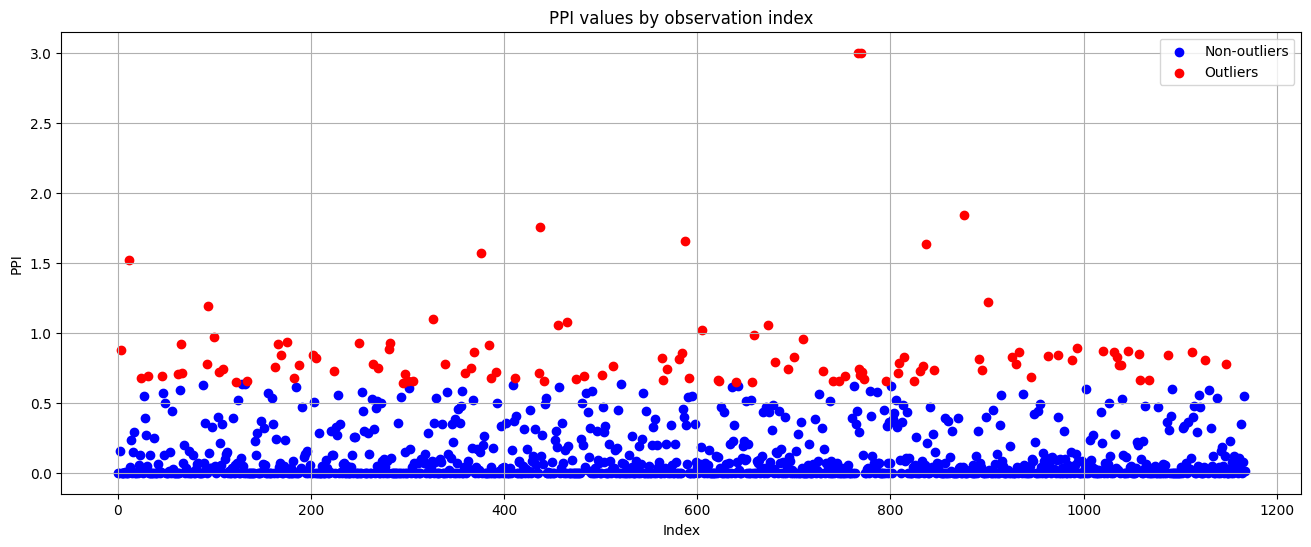

In [ ]:
plt.figure(figsize=(16, 6))
plt.scatter(gdf_bul_no_outliers.index, gdf_bul_no_outliers["ppi"], label="Non-outliers", color='blue')
plt.scatter(outliers.index, outliers["ppi"], label="Outliers", color='red')


plt.xlabel("Index")
plt.ylabel("PPI")
plt.title("PPI values by observation index")
plt.legend()
plt.grid(True)

plt.show()


Let's look at a histogram of the empirical distribution of PPI values to determine whether it is approximately normal. For this plot, I used all PPI observations.

Text(0.5, 1.0, 'Histogram of all PPI values with 50 bins')

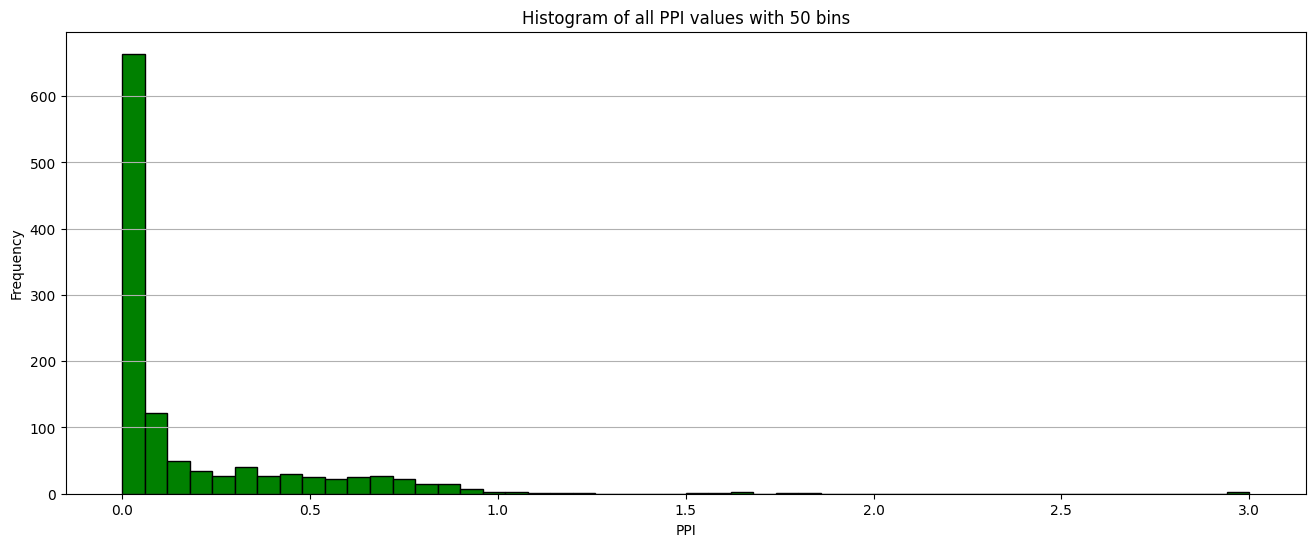

In [ ]:
num_bins=50

plt.figure(figsize=(16,6))
plt.hist(gdf_bul_all["ppi"], bins=num_bins, color='green', edgecolor='black')
plt.xlabel('PPI')
plt.ylabel('Frequency')
plt.grid(axis="y", alpha=1)
plt.title(f'Histogram of all PPI values with {num_bins} bins')

plt.show()

I used the `.describe()` method to get data about the mean, standard deviation and quantiles.

In [68]:
gdf_bul_all["ppi"].describe()

count    1168.000000
mean        0.177980
std         0.298009
min         0.000000
25%         0.000000
50%         0.034414
75%         0.255342
max         3.000000
Name: ppi, dtype: float64

Following that, I drew a box plot to further visualise the PPI median, quartiles and outliers.

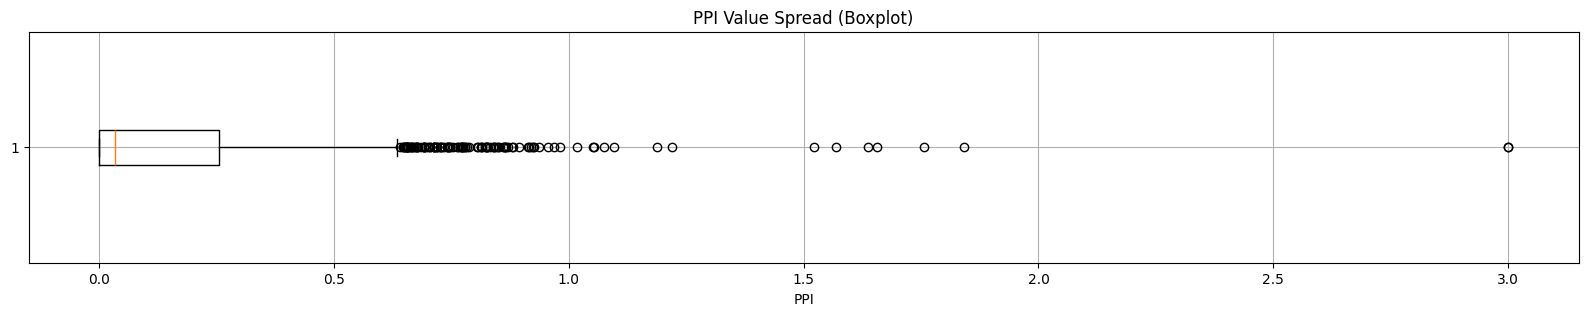

In [ ]:
plt.figure(figsize=(20,3))
plt.boxplot(gdf_bul_all["ppi"], vert=False)
plt.xlabel("PPI")
plt.title('PPI Value Spread (Box plot)')
plt.grid(True)

plt.show()

This dataset is very positively skewed, meaning that the left part of the empirical distribution is much denser than the right part. The distribution is not normal: 50% of the observations are less than or equal to 0.03 and the mean is about 5 times larger than the median.

Finally, I decided to draw a histogram of PPI values without outliers:

Text(0.5, 1.0, 'Histogram of PPI values with 50 bins and outliers excluded')

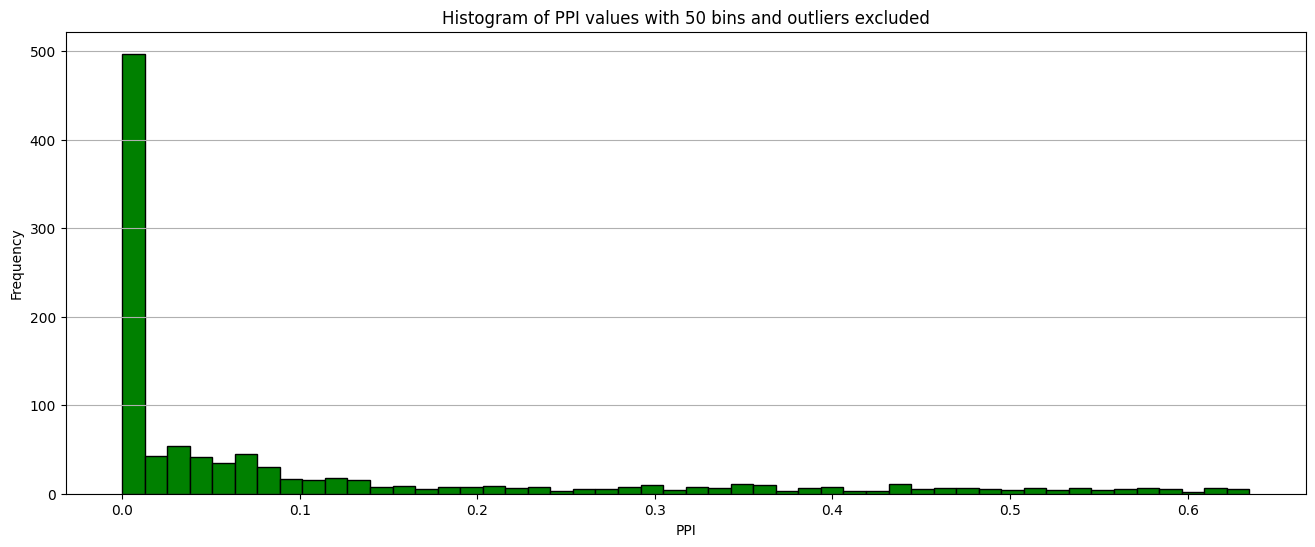

In [ ]:
num_bins=50

plt.figure(figsize=(16,6))
plt.hist(gdf_bul_no_outliers["ppi"], bins=num_bins, color='green', edgecolor='black')
plt.xlabel('PPI')
plt.ylabel('Frequency')
plt.grid(axis="y", alpha=1)
plt.title(f'Histogram of PPI values with {num_bins} bins and outliers excluded')

plt.show()

#### 1.3 Sample the raster RGB values at point locations

I will create two new GeoDataFrames: one for all points and one for points without outliers. Earlier in the code I wrote `s_image=rs.open(image_path)`. This means that `s_image` is a `rasterio.io.DatasetReader` type object. From it we can read, among other things, the number of bands in the satellite image (here it will be red, green and blue, that is 3), but also CRS, width, height and so on. I will use this to get RGB values at each PPI point location.

In [ ]:
coords=[(geom.x,geom.y) for geom in gdf_bul_all.geometry]

samples=list(s_image.sample(coords, indexes=[1,2,3]))
#samples is a list of arrays with each array consisting 
# of three values representing three colours.

r_values=[val[0] for val in samples]
g_values=[val[1] for val in samples]
b_values=[val[2] for val in samples]

gdf_raster_all=gpd.GeoDataFrame(
    {
        'Red': r_values,
        'Green': g_values,
        'Blue': b_values,
        'geometry': gdf_bul_all.geometry
        
    },
    index=gdf_bul_all.index,
    crs=gdf_bul_all.crs
)




In [76]:
gdf_raster_all

,Red,Green,Blue,ppi,geometry
0,82,66,58,0.000000,POINT (564174.994 4825065.027)
1,90,76,59,0.000000,POINT (559224.967 4820994.958)
2,136,103,78,0.158373,POINT (572184.989 4821224.983)
3,39,52,41,0.880115,POINT (560474.991 4814224.964)
4,87,70,63,0.000000,POINT (568035.01 4822115.01)
...,...,...,...,...,...
1163,81,77,63,0.345602,POINT (568505.025 4819635.019)
1164,100,81,67,0.000000,POINT (560235.027 4821814.957)
1165,190,120,95,0.074152,POINT (561515.013 4816774.946)
1166,35,45,36,0.551250,POINT (572454.988 4813804.961)


In [ ]:
coords=[(geom.x,geom.y) for geom in gdf_bul_no_outliers.geometry]

samples=list(s_image.sample(coords, indexes=[1,2,3]))

r_values=[val[0] for val in samples]
g_values=[val[1] for val in samples]
b_values=[val[2] for val in samples]

gdf_raster_no_outliers=gpd.GeoDataFrame(
    {
        'Red': r_values,
        'Green': g_values,
        'Blue': b_values,
        'geometry': gdf_bul_no_outliers.geometry
    },
    index=gdf_bul_no_outliers.index,
    crs=gdf_bul_no_outliers.crs
)

In [78]:
gdf_raster_no_outliers

,Red,Green,Blue,ppi,geometry
0,82,66,58,0.000000,POINT (564174.994 4825065.027)
1,90,76,59,0.000000,POINT (559224.967 4820994.958)
2,136,103,78,0.158373,POINT (572184.989 4821224.983)
4,87,70,63,0.000000,POINT (568035.01 4822115.01)
5,136,102,81,0.000000,POINT (568105.024 4812654.982)
...,...,...,...,...,...
1163,81,77,63,0.345602,POINT (568505.025 4819635.019)
1164,100,81,67,0.000000,POINT (560235.027 4821814.957)
1165,190,120,95,0.074152,POINT (561515.013 4816774.946)
1166,35,45,36,0.551250,POINT (572454.988 4813804.961)


In the second part of this notebook, the RGB columns from `gdf_raster_all` and `gdf_raster_no_outliers` will be covariates for training various models.